In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes', 'gymnasium']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact'), 'gymnasium': ('1.2.3', 'gymnasium[toy-text]==1.2.3', 'gymnasium[toy-text]==1.2.3', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "0114bae219d4d94bc9d18a2e1ab76c089e2dc890"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/0114bae219d4d94bc9d18a2e1ab76c089e2dc890/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Policy Gradient

Value-based methods obtain a policy by maximizing an estimated action-value function. A policy-gradient method instead parameterizes $\pi_\theta(a \mid s)$ directly and optimizes the expected return $J(\theta)$ [@Williams.1992]. The log-derivative identity expresses the gradient as an expectation over trajectories in which the unknown transition probabilities cancel. This produces the REINFORCE estimator, which can be computed from sampled rollouts without a model or value function. On the small FrozenLake problem, we can compare the estimator with the exact gradient and measure how its error changes with batch size.

The derivation below assumes that $\pi_\theta(a\mid s)$ is differentiable
and positive on sampled actions, that the environment dynamics do not
depend on $\theta$, and that differentiation may be interchanged with the
trajectory expectation. We use finite, almost-surely terminating episodes
with bounded rewards, which makes the required expectations finite. The
Monte Carlo estimator is on-policy: its trajectories are sampled from the
same $\pi_\theta$ whose gradient is being estimated. Later sections state
explicitly when an implementation replaces the exact discounted estimator
by a per-step surrogate.

In [1]:
%matplotlib inline
from d2l import jax as d2l
from flax import nnx
import gymnasium as gym
import jax
from jax import numpy as jnp
import numpy as np

## Parameterizing the Policy

We use the FrozenLake environment of the figure with deterministic transitions.

In [2]:
gamma = 0.95
env = gym.wrappers.TimeLimit(
    gym.make('FrozenLake-v1', is_slippery=False).env, max_episode_steps=10_000)

We use deterministic FrozenLake because a nearly random policy reaches the goal too rarely on the slippery version for whole-trajectory REINFORCE to provide a useful signal at this computational budget. We also remove Gymnasium's default 100-step time limit and retain a 10,000-step cap only as a safeguard.

The objective is defined over complete episodes; treating a time-limit truncation as termination would instead optimize a truncated objective. A softmax policy assigns positive probability to every action, so on this finite deterministic map it reaches a terminal state with probability one. In a simulation of 100,000 episodes from the initial uniform policy, none exceeded 80 steps, and the safeguard was never reached. that section uses the same environment and horizon convention.

### Softmax Preferences

Gradient ascent requires a differentiable parameterization of the policy. `ActorCritic.tabular` from that section stores one parameter $\theta_{s,a}$, called a *preference*, for each state-action pair. A softmax converts the preferences at state $s$ into probabilities:

$$\pi_\theta(a \mid s) = \frac{e^{\theta_{s,a}}}{\sum_{a'} e^{\theta_{s,a'}}}.$$

This is the softmax model of that section applied to a state index. It is also the policy class used for behavior cloning, so the same `policy_step` implementation can be reused with different weights. Zero preferences produce the uniform policy. The preferences are policy parameters; unlike $Q(s,a)$, they are not estimates of expected return.

### The Score Function

The softmax is easy to differentiate. Since $\log \pi_\theta(a \mid s) = \theta_{s,a} - \log \sum_{a'} e^{\theta_{s,a'}}$, the derivative with respect to the preference $\theta_{s,b}$ of any action $b$ at the same state is

$$\frac{\partial \log \pi_\theta(a \mid s)}{\partial \theta_{s,b}} = \mathbf{1}(b = a) - \pi_\theta(b \mid s),$$

and the derivative with respect to preferences at other states is zero. The vector $\nabla_\theta\log\pi_\theta(a\mid s)$ is the *score function*. Equation the equation increases the preference of the selected action and decreases the others in proportion to their probabilities. Its components sum to zero, so the update redistributes probability rather than changing its total. The following calculation verifies the identity at a nonuniform parameter table:

In [3]:
rng = np.random.default_rng(0)
theta = jnp.asarray(rng.standard_normal((16, 4)))   # a generic table
score = jax.grad(lambda th: jax.nn.log_softmax(th[6])[2])(theta)
hand = jnp.zeros_like(theta).at[6].set(-jax.nn.softmax(theta[6]))
hand = hand.at[6, 2].add(1.0)
print(bool(jnp.allclose(score, hand, atol=1e-6)))

True


Both implementations confirm the identity. PyTorch differentiates the model's `log_prob`, while JAX differentiates the log-softmax as a function of the parameter table. The subsequent analysis uses the equation to interpret policy updates.

### The Case for Stochastic Policies

Although a deterministic optimal policy exists, stochastic parameterizations are useful for three reasons. First, sampling from the policy provides exploration, although positive probabilities alone do not guarantee adequate visitation in a finite dataset. Second, the softmax is differentiable, whereas an argmax is piecewise constant in its parameters. Third, the same form extends to neural-network policies (that section) and to next-token distributions over a vocabulary (that section).

## The Policy Gradient

We next derive the gradient of expected return with respect to the policy parameters.

### An Optimization Problem over Trajectories

As in that section, suppose the agent starts at state $s_0$ and takes actions from $\pi_\theta$ for $T$ timesteps, producing a trajectory $\tau = (s_0, a_0, r_0, s_1, a_1, r_1, \ldots, s_T)$ with return $R(\tau) = \sum_{t=0}^{T-1} \gamma^t r(s_t, a_t)$. The probability of observing a particular trajectory $\tau$ is the product of the probabilities of each action taken by the agent and each transition made by the environment,

$$P(\tau; \theta) = \prod_{t=0}^{T-1} \pi_\theta(a_t \mid s_t)\ P(s_{t+1} \mid s_t, a_t).$$

If $s_0$ were sampled from the distribution $\mu_0$ of that section, the product would include a factor $\mu_0(s_0)$. This factor is independent of $\theta$, so it does not alter the following derivative. FrozenLake has a fixed start state; in text generation, $\mu_0$ corresponds to a distribution over prompts (that section). The objective is the expected trajectory return,

$$J(\theta) = E_{\tau \sim P(\cdot;\, \theta)} \Big[ R(\tau) \Big] = \sum_{\tau} R(\tau)\ P(\tau; \theta),$$

where the sum ranges over trajectories of length $T$. Episodes that terminate early may be padded with an absorbing state and zero rewards, without changing the objective. The implementation stores only the observed portion of each episode. In the notation of that section, $J(\theta)=V^{\pi_\theta}(s_0)$. We optimize this quantity directly:

$$\max_\theta J(\theta) = \max_\theta \sum_{\tau} R(\tau)\ P(\tau; \theta).$$

The `Batch` class stores transitions from several episodes in flat arrays together with their episode boundaries. It records the `terminated` flag separately from truncation, as required for bootstrapped targets (that section).

In [4]:
class Batch:
    """A flat batch of transitions, plus the episode boundaries."""
    def __init__(self, obs, act, rew, next_obs, term, ep_ends):
        self.obs, self.act, self.rew = obs, act, rew
        self.next_obs, self.term = next_obs, term
        self.ep_ends = ep_ends    # one past the last step of each episode

    def __len__(self):
        return len(self.rew)

    def episodes(self):
        """Yield one slice per episode."""
        start = 0
        for end in self.ep_ends:
            yield slice(start, end)
            start = end

    def episode_returns(self, gamma=1.0):
        """R(tau), the discounted return, one number per episode."""
        return np.array([(gamma ** np.arange(ep.stop - ep.start)
                          * self.rew[ep]).sum() for ep in self.episodes()])

Filling it is a loop over the `evaluate` protocol of that section, a policy being any function `policy(obs, rng) -> action`:

In [5]:
def rollout(env, policy, num_episodes, rng):
    """Collect complete episodes from `policy(obs, rng) -> action` as a
    Batch; `term` records `terminated`, never `truncated` (:numref:`sec_mdp`).

    All sampling runs through the one numpy generator `rng`."""
    cols, ep_ends = [[] for _ in range(5)], []
    for _ in range(num_episodes):
        obs, done = env.reset()[0], False
        while not done:
            act = policy(obs, rng)
            next_obs, reward, terminated, truncated, _ = env.step(act)
            done = terminated or truncated
            for col, val in zip(cols, (obs, act, reward, next_obs,
                                       float(terminated))):
                col.append(val)
            obs = next_obs
        ep_ends.append(len(cols[0]))
    obs, act, rew, next_obs, term = (np.asarray(c) for c in cols)
    return Batch(obs, act, rew.astype(np.float32), next_obs,
                 term.astype(np.float32), np.asarray(ep_ends))

Both objects use NumPy arrays and are shared by the framework implementations. Conversion to framework arrays occurs inside update functions. The same `rollout` function is used by the later learning algorithms.

### The Log-Derivative Trick

To maximize $J(\theta)$ by gradient ascent we need its gradient. The return $R(\tau)$ of a fixed trajectory does not depend on $\theta$, only the probability of the trajectory does, so (the summation is finite, so we can exchange it with the gradient)

$$
\begin{aligned}
\nabla_\theta J(\theta) &= \nabla_\theta \sum_\tau R(\tau)\ P(\tau; \theta) = \sum_\tau R(\tau)\ \nabla_\theta P(\tau; \theta) \\
&= \sum_\tau R(\tau)\ P(\tau; \theta)\ \frac{\nabla_\theta P(\tau; \theta)}{P(\tau; \theta)} \\
&= \sum_\tau P(\tau; \theta)\ R(\tau)\ \nabla_\theta \log P(\tau; \theta),
\end{aligned}
$$

where we multiplied and divided by $P(\tau; \theta)$ and used the identity $\nabla \log P = \nabla P / P$. This step, known as the log-derivative trick, is important because it turns the gradient back into an average over trajectories,

$$\nabla_\theta J(\theta) = E_{\tau \sim P(\cdot;\, \theta)} \Big[ R(\tau)\ \nabla_\theta \log P(\tau; \theta) \Big],$$

This expectation can be estimated by sampling trajectories from the current policy.

### Cancellation of the Transition Probabilities

Although $P(\tau;\theta)$ contains the transition kernel, its derivative does not require evaluating that kernel. Taking the logarithm and differentiating gives

$$
\begin{aligned}
\nabla_\theta \log P(\tau; \theta) &= \nabla_\theta \Big[ \sum_{t=0}^{T-1} \log \pi_\theta(a_t \mid s_t) + \sum_{t=0}^{T-1} \log P(s_{t+1} \mid s_t, a_t) \Big] \\
&= \sum_{t=0}^{T-1} \nabla_\theta \log \pi_\theta(a_t \mid s_t).
\end{aligned}
$$

The transition probabilities do not depend on $\theta$, so their derivatives are zero. The kernel still determines the distribution of sampled trajectories, but the estimator need not evaluate it explicitly.

### The REINFORCE Estimator

We approximate the expectation in the equation with an empirical average. The agent runs its current policy $\pi_\theta$ to collect $n$ trajectories $\tau_1, \ldots, \tau_n$ and computes

$$\hat{u} = \frac{1}{n} \sum_{i=1}^n R(\tau_i)\ \sum_{t=0}^{T-1} \nabla_\theta \log \pi_\theta(a_t^i \mid s_t^i),$$

This is an unbiased estimate of $\nabla_\theta J(\theta)$. REINFORCE [@Williams.1992] applies the ascent step $\theta\leftarrow\theta+\alpha\hat u$. Each trajectory return weights the scores of all actions in that trajectory. On FrozenLake the returns are nonnegative, so sampled actions receive nonnegative weights; their relative probabilities still change through the softmax coupling. Baselines introduced in that section provide weights that are positive for better-than-typical outcomes and negative for worse ones.

Since each update changes the policy, a new on-policy batch is collected before the next update. the figure illustrates one update.

![One REINFORCE step on a one-step problem. The Gaussian policy is $\pi_\theta(a)=\mathcal{N}(a;\mu,1)$ with $\mu=0$, and the reward is $R(a)=0.4+2e^{-(a-2)^2/2}$, giving expected reward $J=0.92$ and exact gradient $\mathrm{d}J/\mathrm{d}\mu=0.52$. (a) Twelve sampled actions increase their log-probabilities in proportion to their rewards. All arrows point upward because all rewards are positive. (b) After the update, the policy mean moves from $0$ to $0.55$, toward the actions with higher rewards.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-rl-score-ascent.svg)

The implementation reuses `policy_step` from that section. Behavior cloning assigned weight one to each demonstrated action; REINFORCE assigns the trajectory return $R(\tau_i)$ to every action in trajectory $i$. The caller supplies the agent and records the number of environment steps:

In [6]:
def train_reinforce(ac, seed, steps, num_updates=256, batch_episodes=16):
    """REINFORCE: a fresh batch from the current policy, every step of a
    trajectory weighted by that trajectory's return, one ascent step."""
    rng = np.random.default_rng(seed)      # one stream for all sampling
    env.reset(seed=seed)
    for _ in range(num_updates):
        batch = rollout(env, ac.act, batch_episodes, rng)
        R = batch.episode_returns(gamma)
        d2l.policy_step(ac, batch,
                        np.repeat(R, np.diff(batch.ep_ends, prepend=0)))
        steps.append(len(batch))
        yield float(R.mean())

Equation the equation divides the summed scores by the number of trajectories $n$, whereas `policy_step` averages over all steps in the batch. On a fixed batch these estimators have the same direction and differ by the mean episode length. Across batches, that factor is random and may correlate with performance. We retain the step-averaged implementation because it is common in practice; that section compares alternative normalizations. The following runs also report the mean return of each training batch as an estimate of $J(\theta)$:

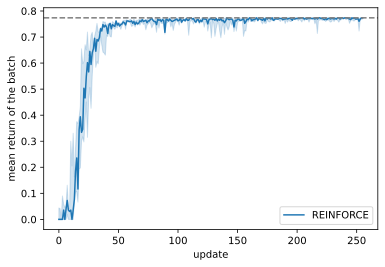

In [7]:
agents, steps, curves = [], [], []
for seed in range(3):
    agents.append(d2l.ActorCritic.tabular(16, 4, rngs=nnx.Rngs(seed)))
    steps.append([])
    curves.append(list(train_reinforce(agents[-1], seed, steps[-1])))
curves, steps = np.array(curves), np.array(steps)
d2l.plot_curves({'REINFORCE': curves}, xlabel='update',
                ylabel='mean return of the batch', reference=gamma ** 5)

Initially, many batches contain no successful trajectory. Their returns and hence their REINFORCE updates are zero. Once successful trajectories occur, their actions become more probable and later successes become more frequent. Within about thirty updates, the mean return exceeds $0.7$ and approaches $\gamma^5\approx0.774$, the return of a six-step path. It remains below this value because the policy is stochastic and sometimes deviates from the shortest path.

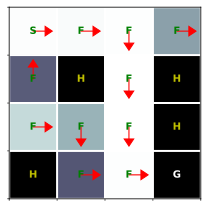

In [8]:
probs = np.exp(agents[0].log_prob_np(np.repeat(np.arange(16), 4),
                                     np.tile(np.arange(4), 16))).reshape(16, 4)
d2l.show_grid(env.unwrapped.desc, probs.max(axis=1), probs.argmax(axis=1))

The arrows show the most probable action in each state, and shading shows its probability. The learned policy concentrates on one of the three optimal six-step paths; the selected path depends on the sampled trajectories and can differ across seeds. The holes and goal remain uniform because actions are never taken from terminal states. Preferences at other states change in proportion to how often those states are visited.

### The Policy Gradient Theorem

REINFORCE weights a whole trajectory's score by the whole trajectory's return. The same gradient can be expressed by state occupancy rather than complete trajectories. Later sections use this form.

**Proposition (policy gradient theorem).** *For the objective $J(\theta) = E_{s_0 \sim \mu_0} [V^{\pi_\theta}(s_0)]$,*

$$\nabla_\theta J(\theta) = E_{\tau \sim P(\cdot;\, \theta)} \Big[ \sum_{t \geq 0} \gamma^t\, \nabla_\theta \log \pi_\theta(a_t \mid s_t)\ Q^{\pi_\theta}(s_t, a_t) \Big] = \frac{1}{1 - \gamma}\, E_{s \sim d^{\pi_\theta}_\gamma,\ a \sim \pi_\theta(\cdot \mid s)} \Big[ \nabla_\theta \log \pi_\theta(a \mid s)\ Q^{\pi_\theta}(s, a) \Big],$$

*where $d^{\pi_\theta}_\gamma(s) = (1 - \gamma) \sum_{t \geq 0} \gamma^t \Pr(s_t = s)$ is the discounted state-occupancy distribution* [@Sutton.McAllester.Singh.ea.2000].

The theorem has three useful consequences. First, the score at time $t$ is weighted by $Q^{\pi_\theta}(s_t,a_t)$ rather than by rewards received before the action was taken; removing those earlier rewards yields the reward-to-go estimator of that section. Second, the occupancy form averages over the discounted frequency with which the policy visits each state, including the effect of the start distribution $\mu_0$. Third, omitting the factors $\gamma^t$, as many implementations do, replaces the discounted occupancy $d^{\pi_\theta}_\gamma$ by an undiscounted visitation distribution. This changes the relative weighting of states and generally produces the gradient of a different objective.

Exercise 6 examines the difference.

## Costs and Limitations

### The On-Policy Data Requirement

The estimator the equation averages trajectories drawn from the *current* policy and approximates an expectation under $P(\tau;\theta)$. After the parameters change, previously collected trajectories no longer follow that distribution. Methods with this requirement are called *on-policy* and ordinarily collect a new batch for each update. Q-learning is *off-policy*: its update can learn about the greedy policy from transitions generated by another behavior policy (that section). We compare their data requirements in environment steps:

In [9]:
hit = (curves >= 0.7).argmax(axis=1)
to_hit = np.array([s[:k + 1].sum() for s, k in zip(steps, hit)])
print(f'update at which the batch mean first reaches 0.7: {np.sort(hit)}')
print(f'environment steps spent by that update:  {np.sort(to_hit)}')
print(f'environment steps spent by the full run: {np.sort(steps.sum(axis=1))}')

update at which the batch mean first reaches 0.7: [24 27 30]
environment steps spent by that update:  [3210 3789 4287]
environment steps spent by the full run: [26058 26582 27472]


Learning required roughly $3{,}000$--$4{,}500$ environment steps, while the complete run used about $27{,}000$. Data collection continues at every on-policy update even after performance has stabilized. The median Q-learning run in that section used $95{,}569$ steps on the harder slippery environment, while its deterministic comparison used 256 episodes on this map. These results are not a controlled algorithm comparison, but they illustrate why interaction should be reported in environment steps.

Exercise 5 reuses a batch for several uncorrected updates and tracks the probability ratio between the updated policy and the policy that collected the data; that section develops a controlled form of such reuse.

### Unbiasedness and Variance

Unbiasedness in the equation means that the expectation of the sampled vector equals $\nabla_\theta J(\theta)$. Exact gradients are generally unavailable, but the sixteen-state example permits a direct comparison. For the softmax policy, writing $P^\pi$ for its transition matrix and $r^\pi$ for its expected one-step reward, the objective of the equation has the closed form

$$J(\theta) = V^{\pi_\theta}(s_0) = \Big[ \big(I - \gamma P^{\pi_\theta}\big)^{-1} r^{\pi_\theta} \Big]_{s_0},$$

a differentiable linear solve, so automatic differentiation gives the exact $\nabla_\theta J$. As in that section, this exact solution provides a reference for a sampled estimator. We evaluate the policy after 16 updates, while its gradient is still appreciable:

In [10]:
mdp = d2l.TabularMDP.from_gym(env, gamma)
P, r = jnp.asarray(mdp.P), jnp.asarray(mdp.r)
probe = d2l.ActorCritic.tabular(16, 4, rngs=nnx.Rngs(3))
for _ in train_reinforce(probe, 3, [], num_updates=16):
    pass

def J_fn(theta):
    pi = jax.nn.softmax(theta, -1)
    return jnp.linalg.solve(jnp.eye(16) - gamma * jnp.einsum('sa,sat->st',
                                                             pi, P),
                            (pi * r).sum(-1))[0]

theta = probe.policy.embedding[...]
g_exact = np.asarray(jax.grad(J_fn)(theta))
print(f'J(theta) after 16 updates = {float(J_fn(theta)):.3f}, '
      f'against the ceiling gamma^5 = {gamma ** 5:.3f}')

J(theta) after 16 updates = 0.313, against the ceiling gamma^5 = 0.774


Now hold $\theta$ fixed and draw the estimator the equation fifty times at each batch size:

In [11]:
def reinforce_estimate(n, rng):
    """One draw of eq_reinforce: n fresh trajectories at the frozen theta."""
    batch = rollout(env, probe.act, n, rng)
    w = jnp.asarray(np.repeat(batch.episode_returns(gamma),
                              np.diff(batch.ep_ends, prepend=0)))
    def surrogate(th):
        logp = jax.nn.log_softmax(th, -1)[batch.obs, batch.act]
        return (w * logp).sum() / n
    return np.asarray(jax.grad(surrogate)(theta)).ravel()

rng, g = np.random.default_rng(4), g_exact.ravel()
for n in [4, 16, 64]:
    U = np.stack([reinforce_estimate(n, rng) for _ in range(50)])
    zero = int((np.linalg.norm(U, axis=1) == 0).sum())
    cos = U.mean(axis=0) @ g / (np.linalg.norm(U.mean(axis=0))
                                * np.linalg.norm(g))
    err = np.linalg.norm(U - g, axis=1).mean() / np.linalg.norm(g)
    print(f'n={n:>3}: zero estimates {zero:>2}/50, cos(mean, exact) = '
          f'{cos:.2f}, single-estimate relative error = {err:.2f}')

n=  4: zero estimates  3/50, cos(mean, exact) = 0.93, single-estimate relative error = 3.64


n= 16: zero estimates  0/50, cos(mean, exact) = 0.97, single-estimate relative error = 1.74


n= 64: zero estimates  0/50, cos(mean, exact) = 1.00, single-estimate relative error = 0.94


The mean of fifty estimates approaches the exact gradient as the batch size grows: its cosine with the exact gradient increases from about $0.93$ to $1.00$. This is consistent with unbiasedness, although cosine similarity alone is not a proof because it does not measure magnitude errors. Individual estimates remain noisy. At $n=4$, the typical error exceeds three and a half times the norm of the true gradient, and some batches contain no successful trajectories and therefore yield a zero estimate. The error decreases approximately as $1/\sqrt{n}$, from about $3.6$ to $1.7$ to $0.9$ as the batch size quadruples. that section evaluates variance-reduction methods against the same exact gradient.

### Nonconcavity of the Objective

The objective $J(\theta)$ is generally nonconcave. The softmax makes it smooth, but a nearly deterministic suboptimal policy can lie on a plateau where the score and gradient are very small. Standard convergence results establish approach to a stationary point under assumptions such as smoothness, bounded estimator variance, and suitable decreasing step sizes. The fixed-rate Adam implementation used here does not satisfy those assumptions. Its success from a uniform initialization on this small environment is therefore empirical rather than a general guarantee.

## Summary

Policy gradient methods optimize a parameterized policy directly. The log-derivative identity expresses $\nabla_\theta J$ as an expectation over trajectory scores, and the transition probabilities vanish from the derivative. REINFORCE estimates this expectation from sampled trajectories. The policy gradient theorem gives an equivalent state-occupancy form weighted by $Q^{\pi_\theta}$. The estimator is unbiased but has sampling error that decreases as $1/\sqrt n$, and it is on-policy, requiring new trajectories after a policy update. The shared `Batch` and `rollout` utilities store and collect these trajectories.

**Experimental scope.** The training curves use three seeds on deterministic FrozenLake; the same estimator is ineffective at this budget on the slippery version. The gradient comparison probes one fixed intermediate policy with fifty samples at each batch size. It supports the predicted unbiasedness and $1/\sqrt{n}$ error scaling, while the numerical constants depend on the selected policy and environment.

## Exercises

1. [conceptual] *The score sums to zero.* Show that the derivative
   the equation sums to zero over $b \in \mathcal{A}$. Conclude
   that one REINFORCE update at a visited state can only *redistribute*
   probability among the actions at that state, never raise all of them.
   Which line of the section's gradient-check cell encodes this identity,
   and what would break if the $-\pi_\theta(b \mid s)$ term were dropped?
1. [short-code] *Unbiased, where enumeration is exact.* Build a two-state,
   two-action MDP with horizon $T = 2$, small enough to enumerate every
   trajectory. Repeat the yardstick measurement there: compute
   $\nabla_\theta J(\theta)$ exactly from the sum in the equation,
   then compute the REINFORCE estimate the equation from
   $n \in \{10, 100, 10000\}$ sampled trajectories, ten times each, and plot
   the mean error and the standard deviation of the estimate against $n$.
   Confirm the $1/\sqrt{n}$ rate. Which of the two numbers does not shrink
   with $n$ at all? Explain why this invariance is useful.
1. [short-code] *Batch size and learning rate.* Sweep `batch_episodes` over
   $\{1, 4, 16, 64\}$ and the learning rate of `ActorCritic.tabular` over
   $\{0.03, 0.1, 0.3\}$, three seeds each, and report for every cell of the
   grid the total number of *episodes* (not updates) consumed before the
   batch mean return first exceeds $0.5$. Which direction of the grid is a
   real improvement, and which merely trades updates for episodes?
1. [conceptual] *Sparse reward, seen from the estimator.* A trajectory that
   never reaches the goal has $R(\tau) = 0$ and drops out of
   the equation entirely. Now change the reward to $-1$ per step
   with $0$ at the goal, which encodes the same preference for short
   successful paths. Does the drop-out problem disappear? Describe the new
   pathology, and say which of the two reward conventions the baseline of
   that section repairs.
1. [short-code] *Breaking the on-policy rule on purpose.* Modify
   `train_reinforce` to reuse each batch for $k$ gradient steps without any
   correction, for $k \in \{1, 2, 5, 20\}$. Alongside the return, log the
   mean and the maximum over the batch of
   $\pi_\theta(a_t \mid s_t) / \pi_{\theta_{\textrm{old}}}(a_t \mid s_t)$ at
   the last of the $k$ steps (`log_prob_np` makes this two lines). At which
   $k$ does the return start to suffer, and what is the ratio doing at that
   point? Keep the diagnostic in mind: it is the central object of
   that section.
1. [conceptual] *The discount that implementations drop.* The trajectory
   form of the policy gradient theorem places a factor $\gamma^t$ in front
   of the score at step $t$. Weighting each step's score by the reward-to-go
   *without* that factor, as the next section will, therefore estimates the
   gradient of a different objective. Write that objective down, say how it
   differs from $J(\theta)$, and give a practical reason why nearly every
   implementation makes this choice anyway.

[Discussions](https://d2l.discourse.group/)